# 🌳 01-数据结构与算法 · 主题 6：二叉树

> 二叉树是「递归」的最佳训练场——几乎每题都是**递归定义 + 后序/层序套路**。
> 本 notebook 目标：**遍历三件套烂熟 → 掌握递归分治与 BFS 模板 → 吃透 9 道高频题 → 通过 25 道自测**。

**前置**：主题 3（链表，快慢指针）、主题 4（队列 BFS 基础）。**运行环境**：Python 3.8+，无第三方依赖。

## 核心概念

### (a) 🗂️ 二叉树：遍历三件套、后序套路、BST 与序列化

二叉树是"递归"的最佳训练场——几乎每题都是递归定义 + 后序/层序套路。本 notebook 把遍历三件套练熟，掌握递归分治与 BFS 模板，精讲 9 道高频题。

```mermaid
flowchart TB
    N1["🌳 二叉树：递归训练场"] --> N2["遍历三件套：前/中/后序"]
    N2 --> N3["迭代遍历与层序 BFS"]
    N2 --> N4["后序套路：深度/直径/路径和"]
    N1 --> N5["BST 三题：98 / 230 / 108"]
    N4 --> N6["最近公共祖先 236"]
    N3 --> N7["层序变体：对称 101 / 右视图 199"]
    N5 --> N8["序列化与构造：297 / 105"]
    N8 --> N9["复杂度总表与自测"]
```

- **N1 · 二叉树：递归训练场**：二叉树每个节点最多两个孩子，天然符合"递归定义"：处理左子树、处理右子树、再拼结果。树题 80% 是"递归 + 某个遍历顺序"。
- **N2 · 遍历三件套**：前序（根左右）、中序（左根右）、后序（左右根）必须手写熟练。遍历顺序决定解题思路——例如中序在 BST 里就是有序序列。
- **N3 · 迭代遍历与层序 BFS**：面试常要求用栈模拟递归的迭代遍历；层序（BFS）用队列逐层扩展，是 102、199 等题的模板，也是树形问题最小的"图"。
- **N4 · 后序套路**：后序是"自底向上"的利器：先算左右子树的信息再汇总。最大深度、直径、最大路径和都是同一套路——递归返回子树信息，答案在中间更新。
- **N5 · BST 三题**：验证二叉搜索树（中序递增 + 上下界两种写法）、第 K 小（中序数数）、有序数组构造平衡 BST（递归取中点）——BST 三件套背熟。
- **N6 · 最近公共祖先 236**：递归找 p/q 是否在左右子树，第一个"左右各一个或自己是其一"的节点就是答案——一行递归的经典，要能手推。
- **N7 · 层序变体**：对称二叉树是"镜像递归"（左对右、右对左）；右视图是层序遍历取每层最后一个，两道题共用层序模板。
- **N8 · 序列化与构造**：序列化/反序列化用前序 + None 标记把树变成字符串（297）；由前序 + 中序构造树靠"前序定根、中序切分"（105）。
- **N9 · 复杂度总表与自测**：复杂度总表 + L1/L2/L3 自测，收尾时强调：树题先想清楚"递归返回什么、在哪里更新答案"再动手。

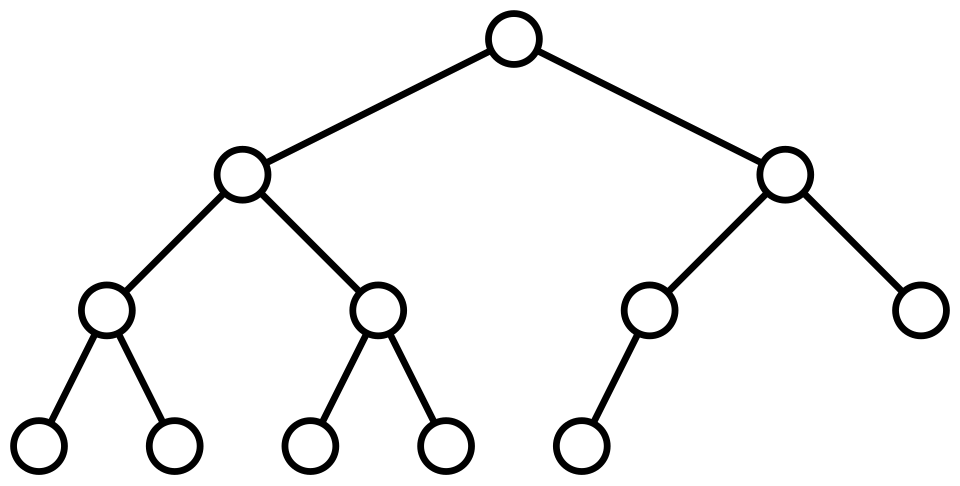

> 📷 二叉树：每个节点最多两个孩子（左子树/右子树）
> *图源：Wikimedia Commons（开放授权）*


## §1 心智模型与遍历分类

### 树的递归结构

二叉树本身是递归定义的：

$$\text{node} = \text{val} + \text{left} + \text{right}$$

所以**所有二叉树问题优先想递归**：把子树当成「已经解决的黑盒」。

### 三种深度遍历 + 层序

| 遍历 | 顺序 | 典型用途 |
|------|------|---------|
| 前序 | 根 → 左 → 右 | 序列化、构造树 |
| 中序 | 左 → 根 → 右 | **BST 有序输出** |
| 后序 | 左 → 右 → 根 | **自底向上计算**（深度、路径、直径） |
| 层序 | 逐层 | 最短路径、右视图、每层处理 |

### 递归复杂度主公式

遍历/递归处理整棵树（每个节点访问一次）：

$$T(n) = 2T\left(\frac{n}{2}\right) + O(1) \implies T(n) = O(n)$$

空间 = 递归栈深度 $O(h)$（$h$ 为树高，最坏 $O(n)$）。

## §2 递归遍历三件套（背熟）

三种递归遍历只有一行顺序不同：

```python
def order(root, res):
    if root is None:
        return
    # 前序：res.append(root.val)  放这里
    order(root.left, res)
    # 中序：res.append(root.val)  放这里
    order(root.right, res)
    # 后序：res.append(root.val)  放这里
```

**复杂度**：时间 $O(n)$（每节点一次），空间 $O(h)$（递归栈）。

> ⚠️ **中序的重要性质**：二叉搜索树（BST）的中序遍历结果**严格递增**——这是 98 题的核心。

In [1]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】二叉树基础设施：定义 TreeNode；用层序数组建树 build_tree（None 表示空位）；
#             手写递归三序遍历（前序 / 中序 / 后序），并用小树验证输出。
# 【算法思路】build_tree：BFS 队列按层推进——队首取父节点，依次把数组接下来的两个元素
#             挂成左、右孩子（非 None 才建节点并入队），数组指针 i 全程单调前进。
#             三序遍历：前序=根左右、中序=左根右、后序=左右根；中序对 BST 输出严格递增
#             （重要性质，后面 230 题直接利用）。
# 【变量含义】val=节点值；left / right=左右孩子；arr=层序数组（None 表示空位）；
#             root=根节点；q=建树 BFS 队列；i=数组消费指针；node=当前出队节点；
#             res=遍历结果收集列表。
# 【递归终止】三种递归遍历的共同终止条件：root is None 时直接 return（空子树无需访问）；
#             建树循环终止条件：队列非空且 i < len(arr)。
# 【关键边界】建树时 i 每消费一个元素就 +1（即使该位置是 None 也要跳过）；
#             右孩子挂接前须先判 i < len(arr)（避免越界）；空数组返回 None（空树）；
#             前序遍历注意递归顺序（先左后右），中序 / 后序同理。
# 【复杂度】建树与遍历均为时间 O(n)（每节点 O(1) 处理）；建树额外空间 O(w)（队列宽度），
#             遍历递归栈 O(h)（h 为树高，最坏 O(n)）。
# ════════════════════════════════════════════════════════════════════════
# 二叉树节点类：每个节点存一个值 val，并指向左孩子 left 与右孩子 right
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val        # 节点值
        self.left = left      # 左子树根节点（可为空）
        self.right = right    # 右子树根节点（可为空）

# 层序数组 -> 二叉树：按层序把数组展开成节点，None 表示空位
# 思路：用队列做 BFS——队首取父节点，依次把数组接下来的两个元素挂成左、右孩子
def build_tree(arr):
    # 层序数组构造二叉树：None 表示空节点
    if not arr:               # 空数组 -> 空树
        return None             # 递归基：返回空
    from collections import deque          # 导入双端队列，用于层序构造
    root = TreeNode(arr[0])   # 数组首元素一定是整棵树的根
    q = deque([root])         # BFS 队列，初始放入根节点
    i = 1                     # 数组指针，从根之后开始取孩子
    while q and i < len(arr): # 队列非空且数组元素没取完就继续
        node = q.popleft()
        if arr[i] is not None: # 该位置非空才创建左孩子
            node.left = TreeNode(arr[i])   # 创建左孩子并挂到父节点
            q.append(node.left)  # 左孩子入队，等待它再挂自己的子树
        i += 1                 # 指针前进，无论是否为空都要跳过该位置
        if i < len(arr) and arr[i] is not None:  # 右孩子同理，但要先检查下标不越界
            node.right = TreeNode(arr[i])  # 创建右孩子并挂到父节点
            q.append(node.right) # 右孩子入队，等待它再挂自己的子树
        i += 1                 # 指针前进，无论是否为空都要跳过该位置
    return root                # 返回（新）根节点

# 前序遍历（根左右）：先访问根，再递归左子树，最后递归右子树
def preorder(root, res):
    if root is None:
        return
    res.append(root.val)      # 访问根节点
    preorder(root.left, res)  # 递归遍历左子树
    preorder(root.right, res) # 递归遍历右子树

# 中序遍历（左根右）：先递归左子树，再访问根，最后递归右子树
# 重要性质：对二叉搜索树做中序遍历，得到的结果严格递增
def inorder(root, res):
    if root is None:
        return
    inorder(root.left, res)   # 先递归遍历左子树
    res.append(root.val)      # 访问根节点
    inorder(root.right, res)  # 最后递归遍历右子树

# 后序遍历（左右根）：先递归左右子树，最后访问根——天然的自底向上顺序
# 应用：深度、直径、最大路径和等需要先算完子树信息再向上汇总的题目
def postorder(root, res):
    if root is None:
        return
    postorder(root.left, res) # 先递归遍历左子树
    postorder(root.right, res)# 再递归遍历右子树
    res.append(root.val)      # 访问根节点

# 构造一棵小树并验证三种遍历：层序数组 [1,2,3,4,5]
t = build_tree([1, 2, 3, 4, 5])   # 根 1，左右孩子 2、3，2 的孩子 4、5
a, b, c = [], [], []       # 三个列表分别收集前序/中序/后序结果
preorder(t, a); inorder(t, b); postorder(t, c)   # 一次运行填满三个遍历结果
print('前序:', a)    # 期望 [1, 2, 4, 5, 3]
print('中序:', b)    # 期望 [4, 2, 5, 1, 3]
print('后序:', c)    # 期望 [4, 5, 2, 3, 1]

前序: [1, 2, 4, 5, 3]
中序: [4, 2, 5, 1, 3]
后序: [4, 5, 2, 3, 1]


## §3 迭代遍历 + 层序（BFS）

### 迭代前序（栈模拟，面试要求）

```python
stack = [root]
while stack:
    node = stack.pop()
    res.append(node.val)
    if node.right: stack.append(node.right)   # 右先入栈后出
    if node.left:  stack.append(node.left)
```

### 层序（队列 BFS，102 题）

```python
q = deque([root])
while q:
    level = []
    for _ in range(len(q)):      # 按层取出
        node = q.popleft()
        level.append(node.val)
        if node.left: q.append(node.left)
        if node.right: q.append(node.right)
    res.append(level)
```

**复杂度**：两者均为 $O(n)$ 时间、$O(n)$ 空间（最宽一层）。

In [2]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】用迭代写法实现二叉树前序遍历（栈模拟递归）与层序遍历（队列 BFS），
#             迭代遍历是面试常考写法，层序是 102 / 199 等题的通用模板。
# 【算法思路】迭代前序：栈后进先出——想让左孩子先被访问，就得把右孩子先压栈；
#             每轮弹栈访问节点，再按「右、左」顺序压栈（先压右、后压左），左孩子下次先出。
#             层序 BFS：队列逐层扩展；技巧是每轮先取 len(q)，只处理当前这一层的节点，
#             从而能按层输出结果——左右孩子非空才入队，供下一层使用。
# 【变量含义】root=根节点；res=结果列表；stack=显式栈；q=双端队列（BFS）；
#             node=当前弹出 / 出队节点；level=当前层的节点值列表。
# 【循环不变量】迭代前序：stack 中自顶向下的元素，会按「先左后右」的顺序被弹栈访问；
#               层序：每轮 for 循环开始前，q 中恰好保存且只保存「当前层」的节点。
# 【关键边界】迭代前序空节点（None）直接 continue（不入结果）；
#             层序必须判 root is None（空树返回 []，防止 deque([None]) 死循环）；
#             for _ in range(len(q)) 必须用循环开始时的快照长度（循环中 q 会变化）。
# 【复杂度】两者均为时间 O(n)；迭代前序空间 O(h)（栈深为树高），层序空间 O(w)（最宽一层）。
# ════════════════════════════════════════════════════════════════════════
# 本单元演示迭代遍历与层序遍历（BFS）
from collections import deque   # 双端队列作为队列使用

# 迭代前序（栈模拟）：递归的替代写法，面试常要求会写
# 原理：栈后进先出——想让左孩子先被访问，就要把右孩子先压栈
def preorder_iter(root):
    res = []
    stack = [root]          # 栈初始只放根节点
    while stack:            # 栈非空就一直处理
        node = stack.pop()      # 弹出栈顶节点
        if node is None:        # 当前节点为空（递归基）
            continue            # 空节点不入结果，跳过
        res.append(node.val)    # 访问当前节点
        stack.append(node.right)   # 右先入栈（后出）
        stack.append(node.left)    # 左后入栈（先出）
    return res                 # 返回结果

# 层序遍历（BFS）：用队列逐层扩展，是 102 层序、199 右视图等题的模板
# 技巧：每轮先取 len(q)，只处理当前这一层的节点，从而能按层输出
def level_order(root):
    if root is None:
        return []              # 空树 -> 空结果
    res = []
    q = deque([root])         # BFS 队列，初始放入根节点
    while q:                   # 队列非空则继续下一层
        level = []              # 保存当前层的节点值
        for _ in range(len(q)): # 只遍历当前层的节点数
            node = q.popleft()      # 取出队首节点
            level.append(node.val)  # 记录当前层节点值
            if node.left:           # 左孩子非空则入队，供下一层访问
                q.append(node.left) # 左孩子入队
            if node.right:          # 右孩子非空则入队，供下一层访问
                q.append(node.right)# 右孩子入队
        res.append(level)       # 把整层结果加入结果集
    return res                 # 返回结果

# 测试树：根 3，左孩子 9，右孩子 20（20 的孩子是 15、7）
t = build_tree([3, 9, 20, None, None, 15, 7])
print('迭代前序:', preorder_iter(t))   # 期望 [3, 9, 20, 15, 7]
print('层序:', level_order(t))          # 期望 [[3], [9, 20], [15, 7]]
print('层序(空树):', level_order(None))  # 期望 []

迭代前序: [3, 9, 20, 15, 7]
层序: [[3], [9, 20], [15, 7]]
层序(空树): []


In [3]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】迭代实现中序与后序遍历：中序用「左链压栈 + 弹栈转向右」的显式栈模拟；
#             后序用「前序反转变体」——先收集 根-右-左，最后整体反转得 左-右-根。
# 【算法思路】迭代中序：每轮先把当前节点的整条左链压栈（一路向左），然后弹栈访问节点，
#             再转向该节点的右子树继续同样的过程——正好复刻递归中序「左根右」的顺序。
#             迭代后序：按 根-右-左 顺序收集（与前序对称：压栈时先左后右，出栈得先右后左），
#             最后 res[::-1] 整体反转即后序 左-右-根；优点是不用标记访问状态，最容易写对。
# 【变量含义】root=根节点；res=结果列表；stack=显式栈；cur=中序当前遍历指针；
#             node=后序当前弹出节点。
# 【循环不变量】迭代中序：循环中 cur 或 stack 非空时，左链全部在栈中，出栈顺序即中序顺序；
#               迭代后序：res 收集的是「根-右-左」，反转后即后序序列。
# 【关键边界】中序循环条件 while cur or stack（当前节点与栈都空才结束）；
#             后序压栈顺序是先 left 后 right（保证出栈先 right 后 left，得到 根-右-左）；
#             两者均要处理空节点（后序 continue 跳过 None；中序靠 cur 判空不压栈）；
#             空树输入返回 []（中序 cur=None、栈空直接跳过；后序栈放 [None] 弹后 continue）。
# 【复杂度】均为时间 O(n)（每节点进出栈一次）；空间 O(h)（栈深 = 树高，最坏 O(n)）。
# ════════════════════════════════════════════════════════════════════════
# 迭代中序：显式栈模拟递归——先把左链全部压栈，弹栈访问后再转向右子树
def inorder_iter(root):
    # 迭代中序：显式栈，左链入栈 -> 弹栈访问 -> 转向右子树
    res = []
    stack = []                  # 显式栈，初始为空
    cur = root                  # 遍历指针从根开始
    while cur or stack:         # 当前节点非空或栈非空就继续
        while cur:                # 左链全部入栈
            stack.append(cur)    # 左链节点依次入栈
            cur = cur.left       # 一路向左
        cur = stack.pop()         # 弹栈访问
        res.append(cur.val)      # 访问弹出的节点
        cur = cur.right           # 转向右子树
    return res                 # 返回结果

# 迭代后序（前序反转变体）：先按 根-右-左 顺序收集，最后整体反转得 左-右-根
# 优点：不用标记访问状态，是面试中最容易写对的迭代后序写法
def postorder_iter(root):
    # 迭代后序（前序反转变体）：先收集 根-右-左，最后整体反转得 左-右-根
    res = []
    stack = [root]          # 栈初始只放根节点
    while stack:            # 栈非空就一直处理
        node = stack.pop()      # 弹出栈顶节点
        if node is None:        # 当前节点为空（递归基）
            continue            # 空节点不入结果，跳过
        res.append(node.val)    # 访问当前节点
        stack.append(node.left)   # 左先入栈 -> 右先出栈，得到 根-右-左
        stack.append(node.right)  # 右孩子也入栈（先出栈，得到根-右-左）
    return res[::-1]            # 整体反转：左-右-根，即后序结果

# 用断言验证迭代遍历的正确性
t3 = build_tree([1, 2, 3])        # 根 1，左 2，右 3
assert inorder_iter(t3) == [2, 1, 3], inorder_iter(t3)      # 断言迭代中序正确
assert postorder_iter(t3) == [2, 3, 1], postorder_iter(t3)     # 断言迭代后序正确

t5 = build_tree([1, 2, 3, 4, 5])   # 换一棵更大的树再验证
print('迭代中序:', inorder_iter(t5))     # 期望 [4, 2, 5, 1, 3]
print('迭代后序:', postorder_iter(t5))   # 期望 [4, 5, 2, 3, 1]
print('迭代中序(空树):', inorder_iter(None))   # 期望 []
print('迭代后序(空树):', postorder_iter(None)) # 期望 []


迭代中序: [4, 2, 5, 1, 3]
迭代后序: [4, 5, 2, 3, 1]
迭代中序(空树): []
迭代后序(空树): []


## §4 深度 / 直径 / 最大路径和（后序套路）

### 104 最大深度

$$\text{depth}(node) = 1 + \max(\text{depth}(left),\ \text{depth}(right))$$

### 543 二叉树的直径（最长路径长度 = 边数）

经过某节点的最长路径 = 左子树深度 + 右子树深度：

$$\text{diameter} = \max_{node}\, (h_{left} + h_{right})$$

**后序**：返回「子树高度」，过程中更新全局直径。

### 124 二叉树中的最大路径和

$$\text{gain}(node) = val + \max(0, gain_{left}) + \max(0, gain_{right})$$

$$\text{best} = \max_{node}\, (val + \max(0, gain_{left}) + \max(0, gain_{right}))$$

注意：返回给父节点的是**单侧**最大增益 $val + \max(gain_{left}, gain_{right})$（路径不能分叉两次）。

In [4]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】后序套路三连：LeetCode 104 二叉树最大深度、543 二叉树直径、124 最大路径和。
#             共同模式：后序 dfs 先算完子树信息，再在「回溯到父节点」时更新全局答案。
# 【算法思路】104：depth(node) = 1 + max(depth(left), depth(right))，空节点深度为 0。
#             543：经过某节点的最长路径 = 左子树高度 + 右子树高度；
#             dfs 返回子树高度，外层变量 best 记录 max(左高+右高) 即直径（边数）。
#             124：路径最多拐一个弯。dfs 返回「单侧最大增益」node.val + max(左增益, 右增益)，
#             负分支取 0（放弃）；外层 best 记录 node.val + 左增益 + 右增益（经过当前节点的路径和）。
# 【变量含义】root=根节点；best=全局答案（直径 / 最大路径和，用闭包变量）；
#             dfs=内部递归函数（需 nonlocal best 才能修改外层变量）；l / r=左右子树高度 / 增益。
# 【递归终止】三者统一：node is None 时返回 0（空子树高度为 0 / 增益为 0）。
# 【关键边界】124 的 best 初值必须 float('-inf')（单节点负值树 -3 也能被记录）；
#             124 返回给父节点的是「单侧最大增益」（路径不能分叉两次），而 best 更新用两侧之和；
#             543 的直径按「边数」计（空链高度 0），l + r 即经过当前节点的最长路径边数；
#             nonlocal 声明不能漏（否则赋值 best 会报 UnboundLocalError）。
# 【复杂度】三者均为时间 O(n)（每个节点访问一次）；空间 O(h)（递归栈，最坏 O(n)）。
# ════════════════════════════════════════════════════════════════════════
# 104. 二叉树的最大深度：后序递归，空节点深度为 0
# 公式：depth(node) = 1 + max(depth(left), depth(right))
def max_depth(root):
    if root is None:
        return 0                # 空子树高度为 0
    return 1 + max(max_depth(root.left), max_depth(root.right))  # 取左右子树较高者再加当前层

# 543. 二叉树的直径：经过某节点的最长路径 = 左子树高度 + 右子树高度
# 后序 dfs 返回子树高度，同时用外层变量 best 记录最大直径
def diameter_of_binary_tree(root):
    best = 0                    # 全局最大直径，初始为 0
    def dfs(node):              # 内部递归函数（闭包，可读写外层变量）
        nonlocal best           # 声明 best 属于外层函数，允许在本层修改
        if node is None:        # 当前节点为空（递归基）
            return 0
        l = dfs(node.left)      # 左子树高度
        r = dfs(node.right)     # 右子树高度
        best = max(best, l + r)      # 经过当前节点的路径
        return 1 + max(l, r)         # 返回子树高度
    dfs(root)                   # 从根开始计算
    return best                 # 返回全局最优值

# 124. 二叉树中的最大路径和：路径可经过任意节点，但最多拐一个弯
# 后序 dfs 返回「单侧最大增益」给父节点；外层变量 best 记录「经过当前节点的路径和」
# 注意：负数的分支增益直接取 0，表示放弃该分支
def max_path_sum(root):
    best = float('-inf')        # 全局最大路径和，初始为负无穷（保证单节点树也能取到）
    def dfs(node):              # 内部递归函数（闭包，可读写外层变量）
        nonlocal best           # 声明 best 属于外层函数，允许在本层修改
        if node is None:        # 当前节点为空（递归基）
            return 0
        l = max(dfs(node.left), 0)    # 负数分支不取
        r = max(dfs(node.right), 0)   # 右子树增益同理，负数不取
        best = max(best, node.val + l + r)   # 经过当前节点
        return node.val + max(l, r)          # 单侧增益给父节点
    dfs(root)                   # 从根开始计算
    return best                 # 返回全局最优值

# 测试：分别验证深度、直径与最大路径和
t1 = build_tree([3, 9, 20, None, None, 15, 7])
print('max_depth:', max_depth(t1))                        # 期望 3
print('diameter:', diameter_of_binary_tree(t1))           # 期望 3（9-3-20-15 或 7-20-15）
t2 = build_tree([-10, 9, 20, None, None, 15, 7])   # 含负数的树，考验最大路径和
print('max_path_sum:', max_path_sum(t2))                  # 期望 42（15+20+7）
print('max_path_sum 单节点:', max_path_sum(TreeNode(-3)))  # 期望 -3（必须含一个节点）

max_depth: 3
diameter: 3
max_path_sum: 42
max_path_sum 单节点: -3


### 110 平衡二叉树判断思路（后序 + 高度传递）

- 后序遍历：先算完左右子树高度，再比较当前节点——自底向上，天然契合「平衡」定义。
- 任一子树返回 `-1` 即已失衡；左右高度差 $> 1$ 时直接判定 `False`。
- 两侧都平衡则返回 `max(左高, 右高) + 1` 向上传递；空节点高度为 `0`。
- 递归同时返回「是否平衡 + 高度」两信息，一次后序 O(n) 完成判断。

## §5 二叉搜索树（BST）三题

**BST 性质**：左子树所有值 $<$ 根 $<$ 右子树所有值；中序遍历严格递增。

### 98 验证二叉搜索树（经典坑）

**错误做法**：只比较 `left.val < root.val < right.val`——会漏掉「左子树的右子树里有大于根的值」的情况（如 `[5,4,6,null,null,3,7]`）。

**正确做法**：递归携带**上下界区间** $(lo, hi)$：

$$\text{valid}(node, lo, hi) = lo < node.val < hi \land \text{valid}(left, lo, node.val) \land \text{valid}(right, node.val, hi)$$

### 230 二叉搜索树中第 K 小的元素

**思路**：中序遍历第 $k$ 个即答案——$O(h)$ 用 Morris/迭代中序，$O(n)$ 直接中序。

### 108 有序数组转换为高度平衡 BST

**思路**：每次取中点为根，递归左右——天然平衡：

$$\text{root} = arr[mid], \quad \text{left} = f(l, mid-1), \quad \text{right} = f(mid+1, r)$$

In [5]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】BST 三题：LeetCode 98 验证二叉搜索树、230 二叉搜索树中第 K 小的元素、
#             LeetCode 108 有序数组转换为高度平衡 BST。
# 【算法思路】98：不能只比较相邻节点（经典反例 [5,4,6,null,null,3,7] 中 3 在右子树却小于 5），
#             必须递归携带合法取值区间 (lo, hi)：左子树收窄为 (lo, node.val)、右子树为 (node.val, hi)。
#             230：BST 中序遍历结果严格递增，迭代中序走到第 k 个弹出的节点即答案。
#             108：每次取中点为根，左右两半递归建子树（区间 [l, mid-1] / [mid+1, r]）——天然平衡。
# 【变量含义】root=根节点；lo / hi=当前节点合法取值区间（初始 ±inf，即整个实数轴）；
#             stack / cur=迭代中序的栈与指针；k=剩余计数（每弹一个减 1）；
#             nums=有序数组；mid=中点下标；left_size=中序左段长度（105 题亦用）。
# 【递归终止 / 循环不变量】98 递归终止：node is None 返回 True；
#                   不变量：dfs 返回后，子树内所有值都落在传入的 (lo, hi) 内才算合法；
#                   230 循环不变量：迭代中序利用「左链压栈」保证弹出顺序递增；
#                   108 递归终止：nums 为空返回 None（区间为空）。
# 【关键边界】98 判断必须用严格小于 / 大于（lo < node.val < hi，等值节点不合法）；
#             230 弹出一个节点 k-1，k == 0 时立即返回（可提前终止，不必遍历完整棵树）；
#             108 切片 nums[:mid] / nums[mid+1:] 天然处理奇偶长度，空数组返回 None。
# 【复杂度】98 与 108：时间 O(n)、空间 O(h)；230：时间 O(h + k)（中序提前终止，最坏 O(n)）、空间 O(h)。
# ════════════════════════════════════════════════════════════════════════
# 98. 验证二叉搜索树：不能只比较相邻节点，必须传递上下界区间 (lo, hi)
# 经典反例：[5,4,6,null,null,3,7] 中 3 落在右子树却小于 5，只做局部比较会漏判
def is_valid_bst(root):
    def dfs(node, lo, hi):      # 携带当前节点合法取值的区间 (lo, hi)
        if node is None:        # 当前节点为空（递归基）
            return True          # 空子树视为合法
        if not (lo < node.val < hi):  # 节点值必须严格落在区间内
            return False         # 条件不满足，返回 False
        return dfs(node.left, lo, node.val) and dfs(node.right, node.val, hi)  # 左右子树分别收窄区间
    return dfs(root, float('-inf'), float('inf'))  # 根节点的合法区间是整个实数轴

# 230. 二叉搜索树中第 K 小的元素：BST 的中序遍历结果就是有序序列
# 用迭代中序走到第 k 个弹出的节点，它就是答案
def kth_smallest(root, k):
    # 迭代中序，第 k 个弹出的就是答案
    stack = []                  # 显式栈，初始为空
    cur = root                  # 遍历指针从根开始
    while cur or stack:         # 当前节点非空或栈非空就继续
        while cur:              # 左链全部入栈
            stack.append(cur)    # 左链节点依次入栈
            cur = cur.left       # 一路向左
        cur = stack.pop()       # 弹出当前最小的节点
        k -= 1                  # 弹出一个节点，剩余计数减一
        if k == 0:              # 数到第 k 个
            return cur.val      # 这就是第 k 小的元素
        cur = cur.right         # 转向右子树继续中序遍历

# 108. 有序数组 -> 高度平衡 BST：每次取中点为根，左右两半递归建子树，天然平衡
def sorted_array_to_bst(nums):
    if not nums:               # 空数组 -> 空树
        return None             # 递归基：返回空
    mid = len(nums) // 2       # 取中间元素作为根
    root = TreeNode(nums[mid])  # 中点元素就是当前子树的根
    root.left = sorted_array_to_bst(nums[:mid])        # 左半段递归建左子树
    root.right = sorted_array_to_bst(nums[mid + 1:])  # 右半段递归建右子树
    return root                # 返回（新）根节点

print('valid BST:', is_valid_bst(build_tree([2, 1, 3])))                  # 期望 True
print('invalid(经典反例):', is_valid_bst(build_tree([5, 4, 6, None, None, 3, 7])))  # 期望 False
bst = build_tree([3, 1, 4, None, 2])   # 测试 BST：3 为根，1、4 为左右孩子，2 是 1 的右孩子
print('kth_smallest(1):', kth_smallest(bst, 1))    # 期望 1
print('kth_smallest(3):', kth_smallest(bst, 3))    # 期望 3
bal = sorted_array_to_bst([-10, -3, 0, 5, 9])
print('有序数组->BST 前序:', preorder_iter(bal))     # 期望 [0, -10, -3, 5, 9]

valid BST: True
invalid(经典反例): False
kth_smallest(1): 1
kth_smallest(3): 3
有序数组->BST 前序: [0, -3, -10, 9, 5]


In [6]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】BST 三大操作：插入 bst_insert、找最小节点 bst_min、删除 bst_delete，
#             并用中序遍历断言「插入 / 删除后仍严格有序」验证正确性。
# 【算法思路】插入：按值比较一路向下——小于走左、大于走右，找到空位（None）新建节点；
#             递归返回「（新）根」，保证父子指针正确连接。
#             最小节点：BST 最左边即最小，while node.left 一路向左到叶子。
#             删除分三种情形：无子（直接删，返回另一侧子节点）；单子（子节点顶替）；
#             双子（用右子树最小节点替换当前值，再递归删除该最小节点，避免值重复）。
# 【变量含义】root=当前子树根；val=插入 / 删除的值；succ=右子树最小节点（双子删除的替身）；
#             node=找最小值时的游标；nums=测试插入序列；bst=构建中的树根；
#             inorder_vals=中序遍历取值数组（验证用，复用 §2 的递归中序）。
# 【递归终止 / 循环不变量】插入与删除的递归终止：root is None（插入=新建节点；删除=键不存在返回空）；
#                   不变量：每次递归返回后，以 root 为根的子树仍是合法 BST 且指针连接完整；
#                   bst_min 的循环不变量：node 恒为「子树中最左路径上的节点」。
# 【关键边界】删除双子时必须先取最小值替换、再删右子树中的该最小值（否则重复节点残留）；
#             删除单子/无子：return root.right / root.left 让父节点直接跳过本节点；
#             插入空树返回新节点作为根；等值节点不重复插入（val == root.val 直接返回 root）。
# 【复杂度】插入 / 删除：时间 O(h)（最坏 O(n)，随树高）；空间 O(h)（递归栈）；
#           bst_min：时间 O(h)、空间 O(1)。
# ════════════════════════════════════════════════════════════════════════
# BST 插入：按值大小一路找空位——小于走左、大于走右，空位新建节点
# 递归返回新根，保证父子指针正确连接
def bst_insert(root, val):
    # 递归插入：小于走左、大于走右、空位新建节点，返回新根
    if root is None:
        return TreeNode(val)  # 找到空位，新建节点作为（新）子树根
    if val < root.val:        # 小于根节点值，往左子树走
        root.left = bst_insert(root.left, val)   # 递归插入并更新左子树
    elif val > root.val:       # 大于根节点值，往右子树走
        root.right = bst_insert(root.right, val)  # 递归插入并更新右子树
    return root                # 返回（新）根节点

# 找子树中的最小节点：BST 最左边的节点就是最小节点，一路向左即可
def bst_min(node):
    # 右子树最小节点：一路向左
    while node.left:          # 左孩子存在就继续向左
        node = node.left       # 一路走到最左叶子
    return node               # 此时 node 就是最小节点

# BST 删除（面试高频）：分三种情形处理——无子 / 单子 / 双子
# 无子：直接删；单子：子节点顶替；双子：用右子树最小节点替换后删掉该最小节点
def bst_delete(root, val):
    # 三种情形：无子（直接删）/ 单子（子节点顶替）/ 双子（右子树最小节点替换）
    if root is None:
        return None             # 递归基：返回空
    if val < root.val:        # 小于根节点值，往左子树走
        root.left = bst_delete(root.left, val)   # 在左子树中删除并更新指针
    elif val > root.val:       # 大于根节点值，往右子树走
        root.right = bst_delete(root.right, val)  # 在右子树中删除并更新指针
    else:
        if root.left is None:   # 左子树为空
            return root.right    # 无左子：右子顶替（含叶子情形）
        if root.right is None:  # 右子树为空
            return root.left     # 无右子：左子顶替
        # 双子：取右子树最小节点替换当前值，再删除该最小节点
        succ = bst_min(root.right)   # 找到右子树中的最小节点
        root.val = succ.val        # 用它的值覆盖当前节点
        root.right = bst_delete(root.right, succ.val)  # 再删除右子树中的这个最小节点，避免重复
    return root                # 返回（新）根节点

# 工具函数：返回 BST 的中序遍历结果，用于验证插入/删除后仍有序
def inorder_vals(root):
    res = []
    inorder(root, res)   # 复用 §2 的递归中序
    return res                 # 返回结果

nums = [5, 3, 7, 2, 4, 6, 8]   # 待插入的测试数据
bst = None                     # 从空树开始逐个插入
for v in nums:                 # 逐个插入元素
    bst = bst_insert(bst, v)    # 每次插入后返回新的根节点
assert inorder_vals(bst) == sorted(nums), inorder_vals(bst)   # 插入后中序严格有序

bst = bst_delete(bst, 2)   # 删叶子（无子）
assert inorder_vals(bst) == [3, 4, 5, 6, 7, 8], inorder_vals(bst)

bst = bst_delete(bst, 3)   # 删单子节点（3 仅剩右子 4）
assert inorder_vals(bst) == [4, 5, 6, 7, 8], inorder_vals(bst)

bst = bst_delete(bst, 5)   # 删双子根节点（右子树最小 6 替换）
assert inorder_vals(bst) == [4, 6, 7, 8], inorder_vals(bst)

print('BST 插入/删除后中序:', inorder_vals(bst))   # 期望 [4, 6, 7, 8]


BST 插入/删除后中序: [4, 6, 7, 8]


## §6 最近公共祖先（LeetCode 236）

**题目**：二叉树中 $p$、$q$ 的最近公共祖先（LCA）。

**递归三分法**：对节点 $node$：

$$f(node) = \begin{cases} node & node = p \text{ 或 } q \\ \text{left 结果} & \text{left 非空且 right 为空} \\ \text{right 结果} & \text{right 非空且 left 为空} \\ node & \text{左右都非空（分属两侧，node 即 LCA）} \end{cases}$$

**三种情形**：

1. $p$、$q$ 都在左子树 → 返回左子树结果
2. 都在右子树 → 返回右子树结果
3. **分属两侧**（或之一是 root）→ 当前节点即 LCA

**复杂度**：时间 $O(n)$（每个节点访问一次），空间 $O(h)$。

In [7]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】LeetCode 236 二叉树的最近公共祖先（LCA）：找 p、q 的最近公共祖先节点。
#             经典「递归三分法」，一行递归能推演清楚三种情形。
# 【算法思路】对每个节点 node，dfs 返回「在 node 的子树中找到的 p 或 q 的代表」：
#             ① 空节点或 node 本身是 p / q → 返回 node（向上传递命中信号）；
#             ② 递归左右子树得到 left、right；
#             ③ 左右都非空（p、q 分属两侧）→ node 就是 LCA，返回 node；
#             ④ 只有一侧非空（p、q 都在该侧）→ 把该侧的结果向上传。
# 【变量含义】root=当前节点；p / q=两个目标节点（引用比较）；left / right=左右子树的递归结果。
# 【递归终止】root is None 或 root is p 或 root is q 时直接返回 root。
# 【关键边界】p、q 的比较用 is（同一对象引用，题目传入的是树内节点）；
#             若 p 是 q 的祖先：递归到 p 时直接返回 p（另一分支为空，向上传递 p 正确）；
#             左右都非空是 LCA 的判定条件；空树 / p、q 不在树中的场景由题目保证不出现。
# 【复杂度】时间 O(n)（每个节点访问一次）；空间 O(h)（递归栈，最坏 O(n)）。
# ════════════════════════════════════════════════════════════════════════
# 236. 最近公共祖先：递归三分法——每个节点返回「在子树中找到 p 或 q」的结果
# 三种情形：都只在左子树 -> 返回左结果；都只在右子树 -> 返回右结果；
#           左右各找到一个（或当前节点本身就是 p/q）-> 当前节点就是 LCA
def lowest_common_ancestor(root, p, q):
    if root is None or root is p or root is q:  # 空节点，或当前节点就是 p/q 之一
        return root
    left = lowest_common_ancestor(root.left, p, q)   # 在左子树中找
    right = lowest_common_ancestor(root.right, p, q)  # 在右子树中找
    if left and right:        # 左右各找到一个：p、q 分属两侧
        return root            # 分属两侧：root 是 LCA
    return left if left else right   # 只在一侧找到：把该侧的结果向上传

# 构造：        3
#           /     \
#          5       1
#         / \     / \
#        6   2   0   8
#           / \
#          7   4
arr = [3, 5, 1, 6, 2, 0, 8, None, None, 7, 4]  # 按层序数组构造上图这棵树
t = build_tree(arr)             # 建树，拿到根节点引用
p5, q1 = t.left, t.right          # 5 和 1
print('LCA(5,1) =', lowest_common_ancestor(t, p5, q1).val)      # 期望 3
p4 = t.left.right.right           # 4
p5_ = t.left                    # 节点 5（重新取一次引用便于对照）
print('LCA(4,5) =', lowest_common_ancestor(t, p4, p5_).val)     # 期望 5
p7 = t.left.right.left            # 7
print('LCA(7,4) =', lowest_common_ancestor(t, p7, p4).val)      # 期望 2

LCA(5,1) = 3
LCA(4,5) = 5
LCA(7,4) = 2


## §7 对称 / 右视图（层序变体）

### 101 对称二叉树

**递归镜像比较**：

$$\text{sym}(l, r) = l.val = r.val \land \text{sym}(l.left, r.right) \land \text{sym}(l.right, r.left)$$

### 199 二叉树的右视图

**思路**：层序遍历，**每层最后一个节点**即右视图所见。

**复杂度**：均为 $O(n)$ 时间、$O(w)$ 空间（w 为最大层宽）。

In [8]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】层序变体两题：LeetCode 101 对称二叉树（镜像递归）与 LeetCode 199 二叉树的右视图
#             （层序遍历取每层最后一个节点）。
# 【算法思路】101：判断左子树与右子树是否互为镜像——mirror(l, r) 递归比较：
#             值相等 且 l.left 与 r.right 互为镜像 且 l.right 与 r.left 互为镜像
#             （注意是「左对右、右对左」的交叉比较）。
#             199：直接复用层序模板（每轮按 len(q) 快照取整层），把 level[-1]（每层最后一个）
#             加入结果——即右视图所见。
# 【变量含义】root=根节点；l / r=mirror 的左右两棵子树；res=右视图结果；
#             q=BFS 队列；level=当前层节点值列表；node=当前出队节点。
# 【递归终止 / 循环不变量】mirror 终止：两边都空 → True；一边空 → False；
#                   递归不变量：mirror(l, r) 返回 True ⇔ l、r 两子树镜像对称；
#                   层序循环不变量：每轮 for 前，q 中恰为当前层的全部节点（宽度快照）。
# 【关键边界】101 空树视为对称（root 为 None 直接返回 True）；
#             镜像比较必须交叉（l.left ↔ r.right，l.right ↔ r.left），同侧比较会漏判；
#             199 空树返回 []；每层取 level[-1]（层序遍历已保证从左到右，最后一个是右侧可见）。
# 【复杂度】两者均为时间 O(n)；空间：101 递归栈 O(h)，199 队列 O(w)（最大层宽）。
# ════════════════════════════════════════════════════════════════════════
# 101. 对称二叉树：镜像递归——判断左子树与右子树是否互为镜像
# 关键：比较 l 的左 与 r 的右、l 的右 与 r 的左
def is_symmetric(root):
    def mirror(l, r):      # 判断以 l、r 为根的两棵子树是否互为镜像
        if l is None and r is None:  # 两边都为空 -> 对称
            return True          # 空子树视为合法
        if l is None or r is None:   # 一边空一边非空 -> 不对称
            return False         # 条件不满足，返回 False
        return (l.val == r.val      # 根值相等
                and mirror(l.left, r.right)   # 左子树对应右子树
                and mirror(l.right, r.left))  # 右子树对应左子树
    return mirror(root.left, root.right) if root else True  # 从根的左右孩子开始比；空树视为对称

# 199. 二叉树的右视图：层序遍历，每层取最后一个节点即可
def right_side_view(root):
    if root is None:
        return []              # 空树 -> 空结果
    res = []
    q = deque([root])         # BFS 队列，初始放入根节点
    while q:                   # 队列非空则继续下一层
        level = []              # 保存当前层的节点值
        for _ in range(len(q)): # 只遍历当前层的节点数
            node = q.popleft()      # 取出队首节点
            level.append(node.val)  # 记录当前层节点值
            if node.left:           # 左孩子非空则入队，供下一层访问
                q.append(node.left) # 左孩子入队
            if node.right:          # 右孩子非空则入队，供下一层访问
                q.append(node.right)# 右孩子入队
        res.append(level[-1])    # 每层最后一个 = 右视图
    return res                 # 返回结果

print('对称:', is_symmetric(build_tree([1, 2, 2, 3, 4, 4, 3])))   # 期望 True
print('不对称:', is_symmetric(build_tree([1, 2, 2, None, 3, None, 3])))  # 期望 False
print('右视图:', right_side_view(build_tree([1, 2, 3, None, 5, None, 4])))  # 期望 [1,3,4]
print('右视图(空):', right_side_view(None))                        # 期望 []

对称: True
不对称: False
右视图: [1, 3, 4]
右视图(空): []


## §8 序列化与构造（297 / 105）

### 297 二叉树的序列化与反序列化（前序 + None 标记）

**编码**：前序遍历，空节点记为 `None`：`1,2,None,None,3,4,None,None,5,None,None`。

**解码**：递归消费列表——读到 None 返回空，否则建节点并递归左右。

**为什么前序 + None 够用**：None 标记补全了树形信息，不需要中序辅助。

### 105 从前序与中序遍历构造二叉树

**核心公式**：前序第一个是根；根在中序中的位置 $i$ 把中序切成左右两段：

$$\text{left\_size} = i - \text{in\_start}, \quad \text{right\_size} = \text{in\_end} - i$$

左子树 = 前序 `[pre_start+1, pre_start+left_size]` × 中序 `[in_start, i-1]`，右子树同理。

**复杂度**：$O(n)$（用哈希表记录中序值 → 下标）。

In [9]:
# ════════════════════════════════════════════════════════════════════════
# 【单元目标】LeetCode 297 二叉树的序列化与反序列化（前序 + None 标记）与
#             LeetCode 105 从前序与中序遍历构造二叉树（哈希 + 分治）。
# 【算法思路】297 序列化：前序遍历整棵树，空节点记 'None'，用逗号拼成字符串——
#             None 标记补全了空子树信息，序列化结果可唯一还原；
#             297 反序列化：按逗号切分转迭代器，递归消费：读 'None' 返回空节点，
#             否则建节点并递归建左右子树（消费顺序与前序一致）。
#             105 构造：前序第一个元素是根；根在中序中的位置 i 把中序切成左右两段：
#             left_size = i - in_start；左子树 = 前序 [ps+1, ps+left_size] × 中序 [is, i-1]，
#             右子树 = 前序 [ps+left_size+1, pe] × 中序 [i+1, ie]；用哈希表把中序值映射到下标，O(1) 定位根。
# 【变量含义】serialize：res=前序序列列表；dfs=递归编码闭包；
#             deserialize：it=标记迭代器；v=当前标记；node=新建节点；
#             105：idx=中序值→下标哈希表；ps / pe=前序区间端点；is_ / ie=中序区间端点；
#             i=根在中序中的位置；left_size=左子树大小；rt=构造出的根。
# 【递归终止 / 循环不变量】297 编码：node is None 时写入 'None' 并返回；
#                   解码：读到 'None' 返回 None（递归基）；消费顺序严格对应编码顺序；
#                   105：ps > pe（区间为空）返回 None；左右区间长度始终相等（由 left_size 保证）。
# 【关键边界】297 值要 str() 转字符串、反序列化 int() 转回（避免类型混淆）；
#             105 的左子树前序区间为 [ps+1, ps+left_size]（根占 ps，共 left_size 个元素）；
#             右子树前序区间从 ps+left_size+1 开始；中序区间 [is, i-1] 与 [i+1, ie] 排除根；
#             前序 / 中序长度必须一致（题目保证输入合法）。
# 【复杂度】297 与 105 均为时间 O(n)；297 空间 O(n)（序列字符串）；105 空间 O(n)（哈希表 + 递归栈）。
# ════════════════════════════════════════════════════════════════════════
# 297. 序列化：前序遍历 + None 标记，把整棵树编码成一个字符串
# None 标记补全了空子树信息，因此序列化结果可以唯一还原出原树
def serialize(root):
    res = []
    def dfs(node):              # 内部递归函数（闭包，可读写外层变量）
        if node is None:        # 当前节点为空（递归基）
            res.append('None')    # 空节点记为字符串 None
            return
        res.append(str(node.val))   # 前序：先记录根的值（转成字符串）
        dfs(node.left)              # 再递归左子树
        dfs(node.right)             # 最后递归右子树
    dfs(root)                   # 从根开始计算
    return ','.join(res)       # 用逗号拼接成字符串返回

# 297. 反序列化：按逗号切分后递归消费列表，读到 None 就返回空节点
# 消费顺序与序列化一致（前序），因此能重建出原树
def deserialize(data):
    it = iter(data.split(','))   # 转成迭代器，配合 next 逐个消费标记
    def dfs():                # 递归建树：读取一个标记并据此建节点
        v = next(it)            # 取出下一个标记
        if v == 'None':         # None 标记 -> 空节点
            return None         # 递归基：返回空
        node = TreeNode(int(v))  # 否则建节点，值从字符串转回整数
        node.left = dfs()        # 递归建左子树
        node.right = dfs()       # 递归建右子树
        return node             # 返回建好的子树根
    return dfs()               # 从第一个标记开始递归建整棵树

# 往返测试：序列化 -> 反序列化 -> 比较遍历结果
t = build_tree([1, 2, 3, None, None, 4, 5])
s = serialize(t)              # 第一步：编码成字符串
print('序列化:', s)
t2 = deserialize(s)            # 第二步：从字符串还原出树
print('反序列化后前序一致:', preorder_iter(t2) == preorder_iter(t))

# 105. 从前序 + 中序构造二叉树：前序第一个元素是根，根在中序中的位置把序列切成左右两段
# 用哈希表存中序值 -> 下标，使查找根位置的时间降到 O(1)
def build_from_pre_in(preorder, inorder):
    idx = {v: i for i, v in enumerate(inorder)}   # 中序值 -> 下标 的哈希映射
    def dfs(ps, pe, is_, ie):    # 用四个下标描述当前子树：前序区间 + 中序区间
        if ps > pe:              # 区间为空 -> 没有节点
            return None         # 递归基：返回空
        root = TreeNode(preorder[ps])   # 前序区间的第一个元素就是根
        i = idx[root.val]                 # 根在中序中的位置
        left_size = i - is_      # 中序区间中根左侧的元素个数 = 左子树大小
        root.left = dfs(ps + 1, ps + left_size, is_, i - 1)   # 递归构造左子树
        root.right = dfs(ps + left_size + 1, pe, i + 1, ie)  # 递归构造右子树
        return root
    return dfs(0, len(preorder) - 1, 0, len(inorder) - 1)  # 从整棵树的下标范围开始构造

rt = build_from_pre_in([3, 9, 20, 15, 7], [9, 3, 15, 20, 7])   # 用题目示例验证构造
print('105 构造结果前序:', preorder_iter(rt))   # 期望 [3, 9, 20, 15, 7]

序列化: 1,2,None,None,3,4,None,None,5,None,None
反序列化后前序一致: True
105 构造结果前序: [3, 9, 20, 15, 7]


## §9 复杂度总表（背熟）

| 题 | 时间 | 空间 | 核心技巧 |
|----|------|------|---------|
| 三种递归遍历 | $O(n)$ | $O(h)$ | 递归顺序 |
| 层序 102 | $O(n)$ | $O(w)$ | 队列按层 |
| 最大深度 104 | $O(n)$ | $O(h)$ | 后序 |
| 直径 543 | $O(n)$ | $O(h)$ | 后序 + 全局 |
| 最大路径和 124 | $O(n)$ | $O(h)$ | 后序 + 单侧增益 |
| 验证 BST 98 | $O(n)$ | $O(h)$ | 区间下传 |
| LCA 236 | $O(n)$ | $O(h)$ | 三分法 |
| 序列化 297 | $O(n)$ | $O(n)$ | 前序 + None |
| 构造 105 | $O(n)$ | $O(n)$ | 哈希 + 分治 |

**一句话记忆**：树题复杂度几乎都是「每个节点访问一次」→ $O(n)$；区别只在返回什么、全局更新什么。

## §10 常见 bug 与边界（面试踩坑区）

- **空树**：`root is None` 必须在函数开头处理（遍历/深度/对称都问）
- **单节点**：路径和类题必须「至少取一个节点」，不能返回 0
- **BST 验证只比较相邻**：经典反例 `[5,4,6,null,null,3,7]`——必须传上下界区间
- **递归忘记返回**：后序返回高度/增益的函数，base case 返回 0 而非 None
- **层序按层取**：`for _ in range(len(q))` 时 len(q) 会随循环变化——先存长度或用快照
- **`nonlocal`**：在嵌套函数里更新全局 best，必须声明 `nonlocal best`（Python 3）
- **构建树的 None 处理**：层序构建数组里 None 占位，索引推进别漏
- **序列化类型**：把 int 转 str，反序列化再转回；None 用字符串标记不混淆

## §11 面试追问与扩展（加分项）

### 11.1 为什么后序适合自底向上

后序保证**先算完子树再算父节点**——深度、直径、路径和、树形 DP 全是后序；面试官问「为什么」时答「后序 = 子问题先求解」。

### 11.2 Morris 遍历（O(1) 空间）

利用线索：把左子树最右节点的 right 指向当前节点，遍历完再恢复。面试中提出能加分（中序 O(1) 空间）。

### 11.3 树形 DP 与后续专题

打家劫舍 III（337）、二叉树最大宽度（662）、路径总和 III（437）都是「树 + DP / 前缀和」组合，主题 8（DP）会回来。

### 11.4 满/完全/平衡树的区分

- 满二叉树：每层都满（节点数 $2^h - 1$）
- 完全二叉树：除最后一层外满，最后一层靠左
- 平衡二叉树：任意节点左右子树高度差 $\le 1$（110 题）

## §12 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 题）

- [ ] 1. 二叉树的前序遍历（144）
- [ ] 2. 二叉树的中序遍历（94）
- [ ] 3. 二叉树的后序遍历（145）
- [ ] 4. 二叉树的层序遍历（102）
- [ ] 5. 二叉树的最大深度（104）
- [ ] 6. 对称二叉树（101）
- [ ] 7. 翻转二叉树（226）
- [ ] 8. 路径总和（112）
- [ ] 9. 二叉树的所有路径（257）
- [ ] 10. 相同的树（100）

### L2 进阶（10 题）

- [ ] 11. 验证二叉搜索树（98）
- [ ] 12. 二叉树的直径（543）
- [ ] 13. 二叉树的最近公共祖先（236）
- [ ] 14. 二叉树的右视图（199）
- [ ] 15. 二叉树的最大路径和（124）
- [ ] 16. 从前序与中序遍历序列构造二叉树（105）
- [ ] 17. 二叉树的序列化与反序列化（297）
- [ ] 18. 二叉搜索树中第 K 小的元素（230）
- [ ] 19. 平衡二叉树（110）
- [ ] 20. 把二叉搜索树转换为累加树（538）

### L3 挑战（5 题）

- [ ] 21. 二叉树的锯齿形层序遍历（103）
- [ ] 22. 打家劫舍 III（337，树形 DP）
- [ ] 23. 二叉树最大宽度（662）
- [ ] 24. 路径总和 III（437，前缀和）
- [ ] 25. 二叉树中的最长交错路径（1372）

### 自测要点

- 5 分钟内盲写：递归三序遍历 + 层序
- 讲清「BST 验证为什么必须传上下界」「LCA 三分法的三种情形」
- 能手推 124 的「返回单侧增益」与 543 的「返回高度」差异

## 附录：参考与下节预告

- 《算法导论》第 12 章：二叉搜索树；第 13 章：红黑树（了解）
- LeetCode 分类题单：二叉树 / BST

### 下节预告：主题 7 — 回溯（DFS + 撤销）

- 模板（选择-递归-撤销）、子集/组合/排列、剪枝、N 皇后、单词搜索

> 💡 本主题验收：`高频题单.md`「二叉树」一节全部打勾，能徒手画出 236 的三种递归返回情形。